<a href="https://colab.research.google.com/github/fernandodeeke/epidemy/blob/main/sir_basic_cont.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

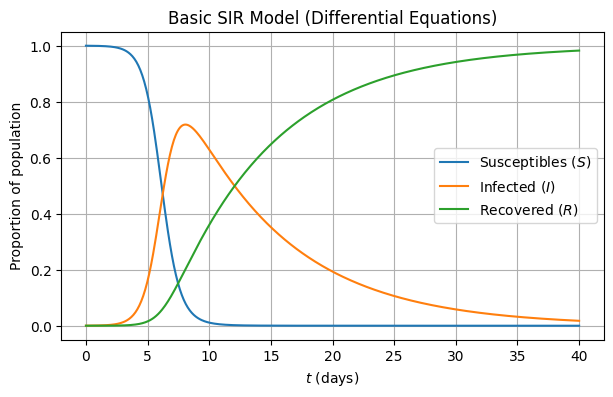

In [ ]:
# Basic SIR Continuous Mode
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Model parameters
beta = 1.5 # Infectiousness
gamma = 0.12 # Recovery rate
T = 40 # Total duration (in days)

#Initial Conditions
S0 = 4999 # Initial number of susceptibles
I0 = 1 # Initial number of infected
R0 = 0.0 # Initial number of recovered
N = S0 + I0 + R0 # Total number of individuals
IC = [S0, I0, R0] # List of initial conditions

# System of equations
def sir(t, y):
  S, I, R = y
  dSdt = -beta * S * I / N
  dIdt = beta * S * I / N - gamma * I
  dRdt = gamma * I
  return [dSdt, dIdt, dRdt]

#  Grid with 500 points for the time interval [0, 50]
time = np.linspace(0, T, 500)

# Solving the initial value problem using the Runge-Kutta method
solution = solve_ivp(sir, [0, T], IC, t_eval=time, method="RK45")
S, I, R = solution.y

# Plot
plt.figure(figsize=(7, 4), dpi=100)
plt.plot(time, S/N, label="Susceptibles ($S$)", lw=1.5)
plt.plot(time, I/N, label="Infected ($I$)", lw=1.5)
plt.plot(time, R/N, label="Recovered ($R$)", lw=1.5)
plt.title("Basic SIR Model (Differential Equations)")
plt.xlabel("$t$ (days)")
plt.ylabel("Proportion of population")
plt.legend()
plt.grid()
plt.savefig("sir_cont1.png", dpi=300) # Save in high resolution
plt.show()